In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('Scenario-A-merged_5s.csv')

df.dropna(inplace=True)

df = df.replace([np.inf, -np.inf], np.nan).dropna()
source_ip_frequency = df['Source IP'].value_counts()
destination_ip_frequency = df[' Destination IP'].value_counts()

df['Source IP'] = df['Source IP'].map(source_ip_frequency)
df[' Destination IP'] = df[' Destination IP'].map(destination_ip_frequency)
df_target=df['label']
df.drop(['label'], axis=1, inplace=True)

print(df.describe()) #to summarize statistics
print(df.info()) #to print info about dataset

train, test = train_test_split(df, test_size=0.2, shuffle=True)

          Source IP   Source Port   Destination IP   Destination Port  \
count  84187.000000  84187.000000     84187.000000       84187.000000   
mean    5031.855476  36550.228301      3063.709920       13160.176868   
std     3609.622725  21514.235930      3172.777986       19548.441624   
min        1.000000     21.000000         1.000000          21.000000   
25%     2113.000000  15685.000000       252.000000         137.000000   
50%     4708.000000  42382.000000      1966.000000         443.000000   
75%     6311.000000  54420.000000      4968.000000       19302.000000   
max    10472.000000  65534.000000      9916.000000       65514.000000   

           Protocol   Flow Duration   Flow Bytes/s   Flow Packets/s  \
count  84187.000000    8.418700e+04   8.418700e+04     8.418700e+04   
mean      11.709254    1.976607e+06   2.693915e+05     2.767573e+03   
std        5.496051    2.143445e+06   5.147994e+06     4.374423e+04   
min        6.000000    1.000000e+00   0.000000e+00     4.0

In [ ]:
#Dataset 1 Binary LOGISTIC REGRESSION CLASSIFIER K-Means
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)


C_list = [0.001, 0.01, 0.1, 1, 10, 100]
penalty_list = ['l1', 'l2', 'elasticnet', 'none']
l1_ratio_list = [0.1, 0.5, 0.9]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a = 0

for C in C_list:
    for penalty in penalty_list:
        a += 1
        print(a)
        if penalty == 'elasticnet':
            for l1_ratio in l1_ratio_list:
                logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', l1_ratio=l1_ratio, random_state=42)
                fold_accuracies = []
                for train_index, test_index in kf.split(train):
                    train_labels = kmeans.fit_predict(train.iloc[train_index])
                    test_labels = kmeans.predict(train.iloc[test_index])
                    logistic_regression.fit(train.iloc[train_index], train_labels)
                    predictions = logistic_regression.predict(train.iloc[test_index])
                    fold_accuracy = accuracy_score(test_labels, predictions)
                    fold_accuracies.append(fold_accuracy)
                mean_accuracy = np.mean(fold_accuracies)
                if mean_accuracy > best_accuracy:
                    best_accuracy = mean_accuracy
                    best_params = {'C': C,
                                   'penalty': penalty,
                                   'l1_ratio': l1_ratio}
        else:
            logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
            fold_accuracies = []
            for train_index, test_index in kf.split(train):
                train_labels = kmeans.fit_predict(train.iloc[train_index])
                test_labels = kmeans.predict(train.iloc[test_index])
                logistic_regression.fit(train.iloc[train_index], train_labels)
                predictions = logistic_regression.predict(train.iloc[test_index])
                fold_accuracy = accuracy_score(test_labels, predictions)
                fold_accuracies.append(fold_accuracy)
            if mean_accuracy > best_accuracy:
                best_accuracy = mean_accuracy
                best_params = {'C': C,
                               'penalty': penalty}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` exp

2


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/loca

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/loca

19


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/loca

20


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behav

In [ ]:
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

Best hyperparameters: {'C': 0.001, 'penalty': 'l1'}
Best accuracy: 0.9121590632684373


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy of Logistic Regression Classifier with KMeans cluster labels: 0.9134101437225324
Accuracy of Logistic Regression Classifier with K-means cluster labels: 0.9134101437225324
Precision: 0.922624814321072
Recall: 0.9134101437225324
F1-score: 0.9146205459040726
Confusion Matrix:
 [[5481    0  222    1]
 [   0    0    3    0]
 [1223    0 9157    0]
 [   1    0    8  742]]


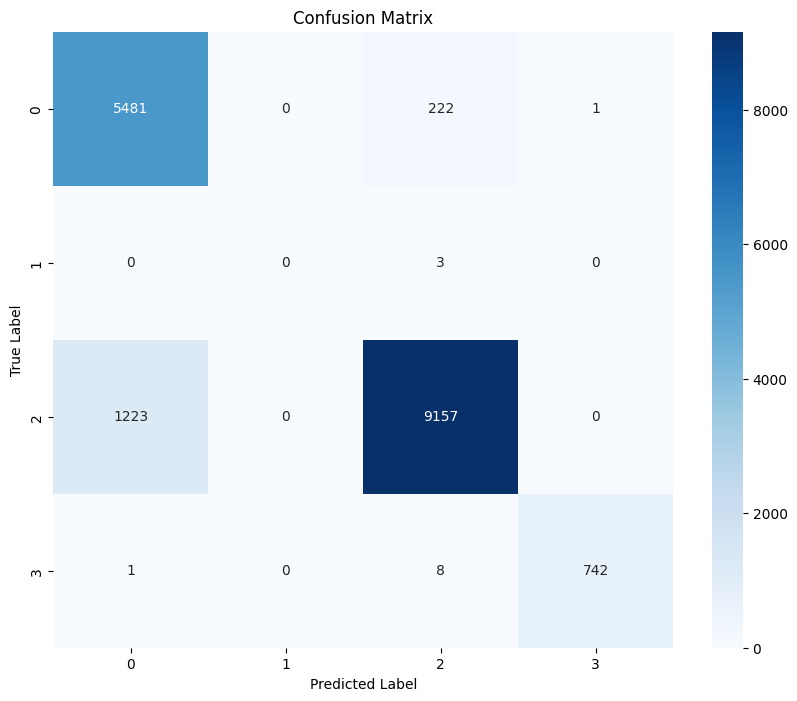

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)
train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

C=0.001
penalty='l1'
logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
logistic_regression.fit(train, train_labels)

predictions = logistic_regression.predict(test)

accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression Classifier with KMeans cluster labels:", accuracy)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Logistic Regression Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 1 Binary LOGISTIC REGRESSION CLASSIFIER GMM
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

C_list = [0.001, 0.01, 0.1, 1, 10, 100]
penalty_list = ['l1', 'l2', 'elasticnet', 'none']
l1_ratio_list = [0.1, 0.5, 0.9]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a = 0

for C in C_list:
    for penalty in penalty_list:
        a += 1
        print(a)
        if penalty == 'elasticnet':
            for l1_ratio in l1_ratio_list:
                logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', l1_ratio=l1_ratio, random_state=42)
                fold_accuracies = []
                for train_index, test_index in kf.split(train):
                    train_labels = gmm.fit_predict(train.iloc[train_index])
                    test_labels = gmm.predict(train.iloc[test_index])
                    logistic_regression.fit(train.iloc[train_index], train_labels)
                    predictions = logistic_regression.predict(train.iloc[test_index])
                    fold_accuracy = accuracy_score(test_labels, predictions)
                    fold_accuracies.append(fold_accuracy)
                mean_accuracy = np.mean(fold_accuracies)
                if mean_accuracy > best_accuracy:
                    best_accuracy = mean_accuracy
                    best_params = {'C': C,
                                   'penalty': penalty,
                                   'l1_ratio': l1_ratio}
        else:
            logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
            fold_accuracies = []
            for train_index, test_index in kf.split(train):

                train_labels = gmm.fit_predict(train.iloc[train_index])
                test_labels = gmm.predict(train.iloc[test_index])
                logistic_regression.fit(train.iloc[train_index], train_labels)
                predictions = logistic_regression.predict(train.iloc[test_index])
                fold_accuracy = accuracy_score(test_labels, predictions)
                fold_accuracies.append(fold_accuracy)
            mean_accuracy = np.mean(fold_accuracies)
            if mean_accuracy > best_accuracy:
                best_accuracy = mean_accuracy
                best_params = {'C': C,
                               'penalty': penalty}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


2


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


3


...

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

24


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/py

Best hyperparameters: {'C': 0.001, 'penalty': 'l1'}
Best accuracy: 0.96270898271465


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy of Logistic Regression Classifier with GMM cluster labels: 0.9654312592088858
Precision: 0.9669256714926441
Recall: 0.9654312592088858
F1-score: 0.9658926882163095
Confusion Matrix:
 [[6386  214    0    0]
 [  91 1551    0    0]
 [   0    0  423    0]
 [   0    0    0  158]]


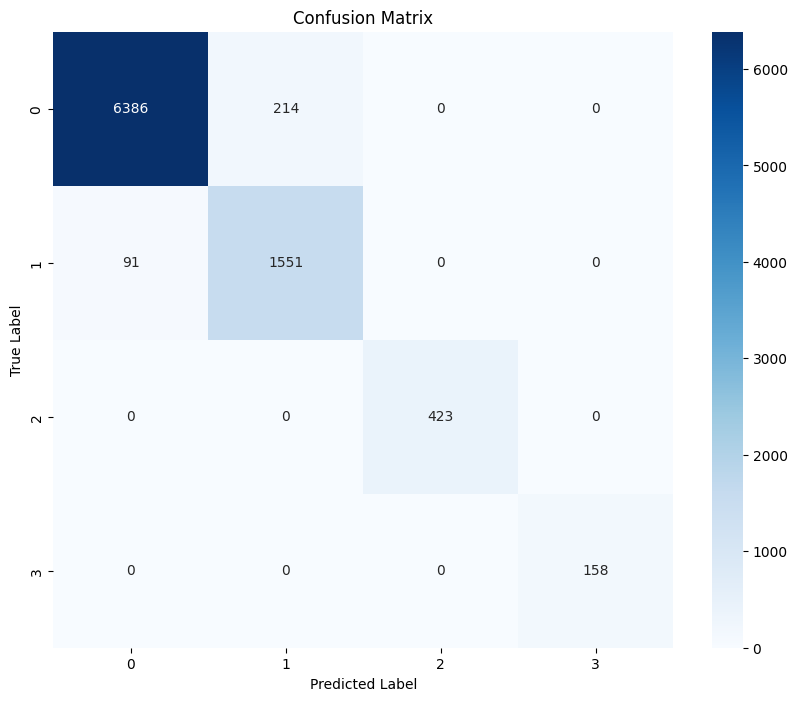

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

C=0.001
penalty='l1'

logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
logistic_regression.fit(train, train_labels)

predictions = logistic_regression.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Logistic Regression Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary LOGISTIC REGRESSION CLASSIFIER Minibatch K-Means
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

k=4
batch_size=100
max_iter=100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

C_list = [0.001, 0.01, 0.1, 1, 10, 100]
penalty_list = ['l1', 'l2', 'elasticnet', 'none']
l1_ratio_list = [0.1, 0.5, 0.9]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a = 0

for C in C_list:
    for penalty in penalty_list:
        a += 1
        print(a)
        if penalty == 'elasticnet':
            for l1_ratio in l1_ratio_list:
                logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', l1_ratio=l1_ratio, random_state=42)
                fold_accuracies = []

                for train_index, test_index in kf.split(train):
                    train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
                    test_labels = minibatch_kmeans.predict(train.iloc[test_index])
                    logistic_regression.fit(train.iloc[train_index], train_labels)
                    predictions = logistic_regression.predict(train.iloc[test_index])
                    fold_accuracy = accuracy_score(test_labels, predictions)
                    fold_accuracies.append(fold_accuracy)
                mean_accuracy = np.mean(fold_accuracies)
                if mean_accuracy > best_accuracy:
                    best_accuracy = mean_accuracy
                    best_params = {'C': C,
                                   'penalty': penalty,
                                   'l1_ratio': l1_ratio}
        else:
            logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
            fold_accuracies = []

            for train_index, test_index in kf.split(train):
                train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
                test_labels = minibatch_kmeans.predict(train.iloc[test_index])
                logistic_regression.fit(train.iloc[train_index], train_labels)
                predictions = logistic_regression.predict(train.iloc[test_index])
                fold_accuracy = accuracy_score(test_labels, predictions)
                fold_accuracies.append(fold_accuracy)
            mean_accuracy = np.mean(fold_accuracies)
            if mean_accuracy > best_accuracy:
                best_accuracy = mean_accuracy
                best_params = {'C': C,
                               'penalty': penalty}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explic

2


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/

24


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib

Best hyperparameters: {'C': 100, 'penalty': 'none'}
Best accuracy: 0.9614054973080194


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy of Logistic Regression Classifier with Minibatch K-means cluster labels: 0.9467301371415618
Precision: 0.9493724735209621
Recall: 0.9467301371415618
F1-score: 0.947170682553523
Confusion Matrix:
 [[3557   18    0   77]
 [   1 1579    0   68]
 [   0    0  581    1]
 [  41  264    0 2636]]


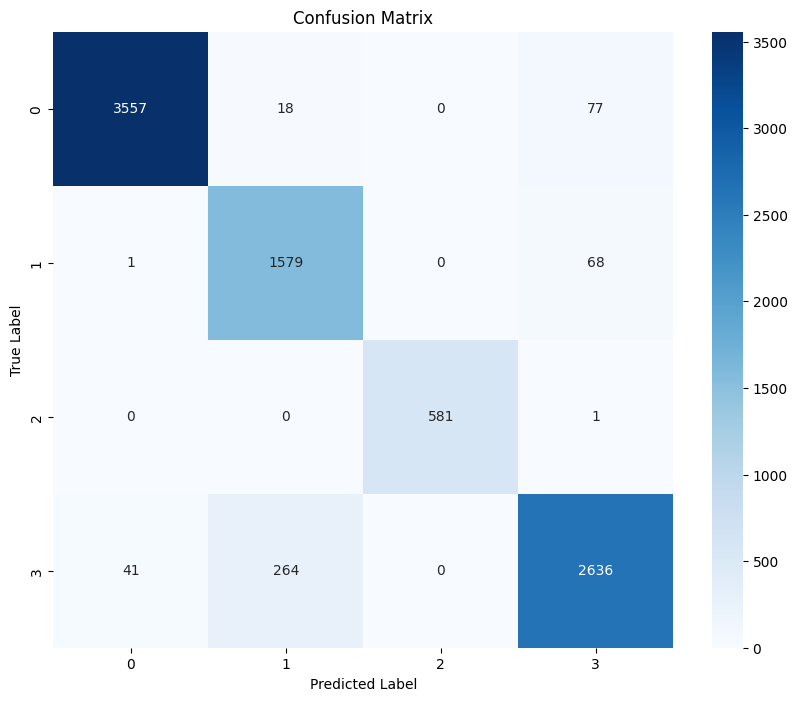

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=4
batch_size=100
max_iter=100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

C=100
penalty=None
logistic_regression = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=42)
logistic_regression.fit(train, train_labels)

predictions = logistic_regression.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Logistic Regression Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary Decision Tree Minibatch K-Means
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)
criterion_list = ['gini', 'entropy']
max_depth_list = [None, 5, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = ['auto', 'sqrt', 'log2', None]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)

    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklear

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

287


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

288


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}
Best accuracy: 0.9983848115613488


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Decision Tree Classifier with Minibatch K-means cluster labels: 0.9973931769239488
Precision: 0.9973971767869255
Recall: 0.9973931769239488
F1-score: 0.9973948770405703
Confusion Matrix:
 [[ 952    0    5    5]
 [   0  582    0    0]
 [   7    0 5801    0]
 [   6    0    0 1465]]


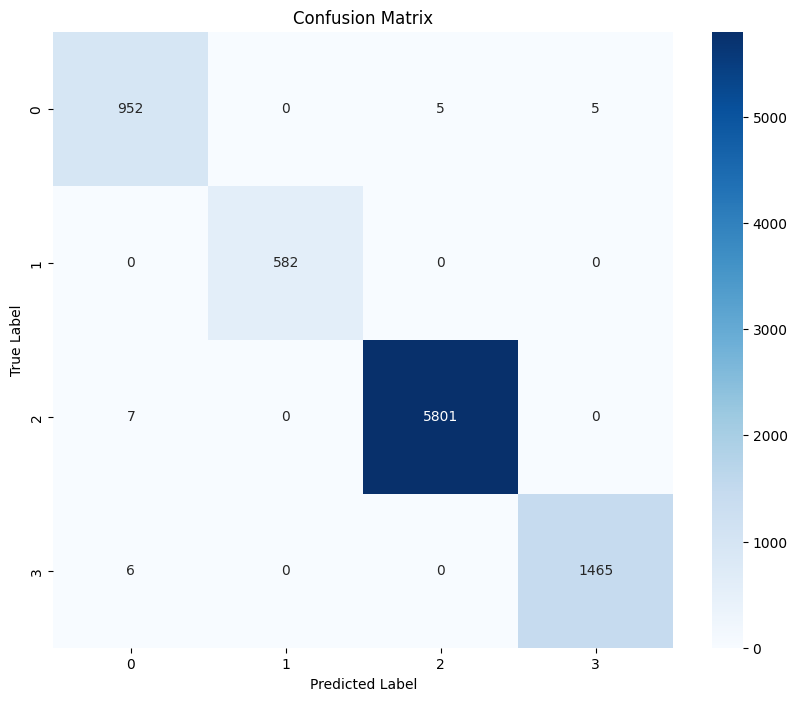

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=4
batch_size=100
max_iter=100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

criterion =  'entropy'
max_depth = 20
min_samples_split = 2
min_samples_leaf = 2
max_features_list = None

dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
dt_classifier.fit(train, train_labels)

predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Decision Tree Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 1 Binary Decision Tree GMM
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

criterion_list = ['gini', 'entropy']
max_depth_list = [None, 5, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = ['auto', 'sqrt', 'log2', None]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)

    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

2
3
4
5


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

6
7
8
9


...

278
279
280
281


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

282
283
284
285


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

286
287
288
Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
Best accuracy: 0.9969679795976196


Accuracy of Decision Tree Classifier with GMM cluster labels: 0.9972798367902074
Precision: 0.9972798367902074
Recall: 0.9972798367902074
F1-score: 0.9972798367902074
Confusion Matrix:
 [[6588   12    0    0]
 [  12 1630    0    0]
 [   0    0  423    0]
 [   0    0    0  158]]


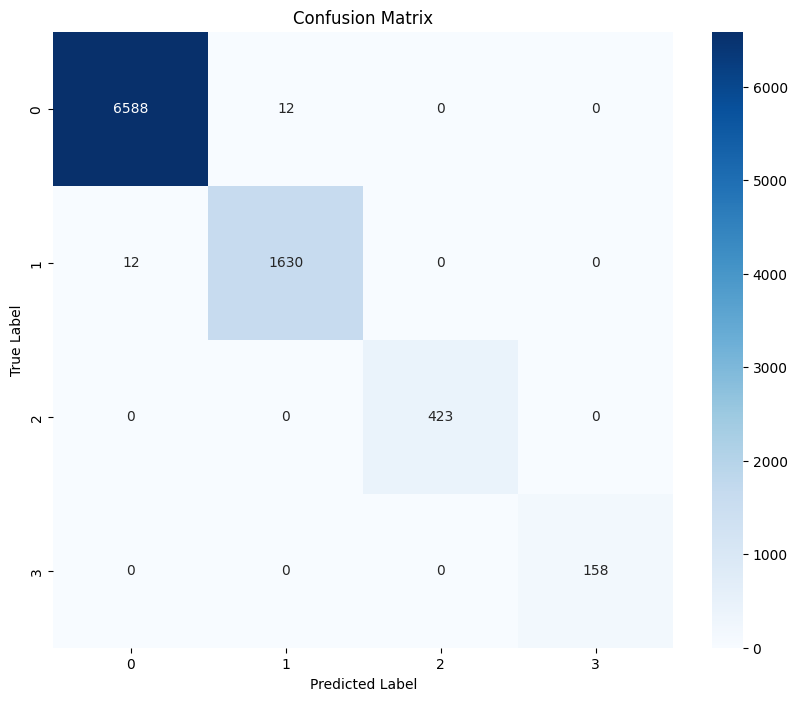

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

criterion =  'entropy'
max_depth = None
min_samples_split = 2
min_samples_leaf = 1
max_features_list = None

dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
dt_classifier.fit(train, train_labels)

predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Decision Tree Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary Decision Tree K-Means
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

criterion_list = ['gini', 'entropy']
max_depth_list = [None, 5, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = ['auto', 'sqrt', 'log2', None]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)
    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skle

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


3


...

287


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

288


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
Best accuracy: 0.9965429300085009


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Decision Tree Classifier with K-means cluster labels: 0.9970531565227247
Precision: 0.9970575149174323
Recall: 0.9970531565227247
F1-score: 0.9970522707598146
Confusion Matrix:
 [[1192    0    3   12    0]
 [   0  424    0    0    0]
 [   4    0 5912    0    0]
 [   5    0    0 1115    0]
 [   0    2    0    0  154]]


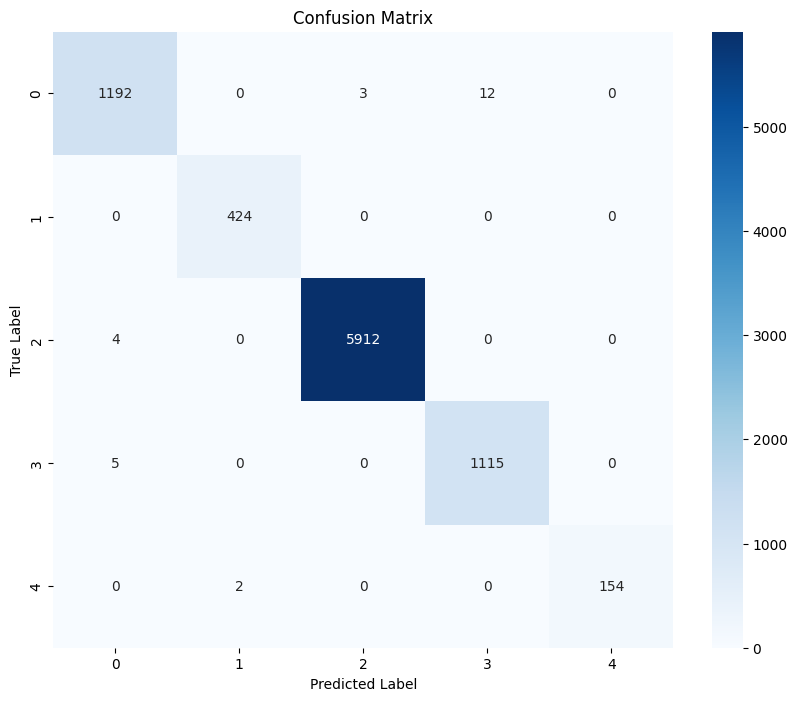

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

criterion =  'entropy'
max_depth = 10
min_samples_split = 2
min_samples_leaf = 1
max_features_list = None

dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)

dt_classifier.fit(train, train_labels)
predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Decision Tree Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary ADABOOST CLASSIFIER Minibatch K-Means
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)


param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.3, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    n_estimators, learning_rate = params

    adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        adaboost_classifier.fit(train.iloc[train_index], train_labels)
        predictions = adaboost_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

11


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

12


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'n_estimators': 100, 'learning_rate': 0.01}
Best accuracy: 0.9594786058373478


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy of AdaBoost Classifier with Minibatch K-means cluster labels: 0.9704182250935056
Precision: 0.9577266956417291
Recall: 0.9704182250935056
F1-score: 0.9629919695393467
Confusion Matrix:
 [[6439    0   89    0]
 [   0  428    0    0]
 [  16    0 1695    0]
 [   0  153    3    0]]


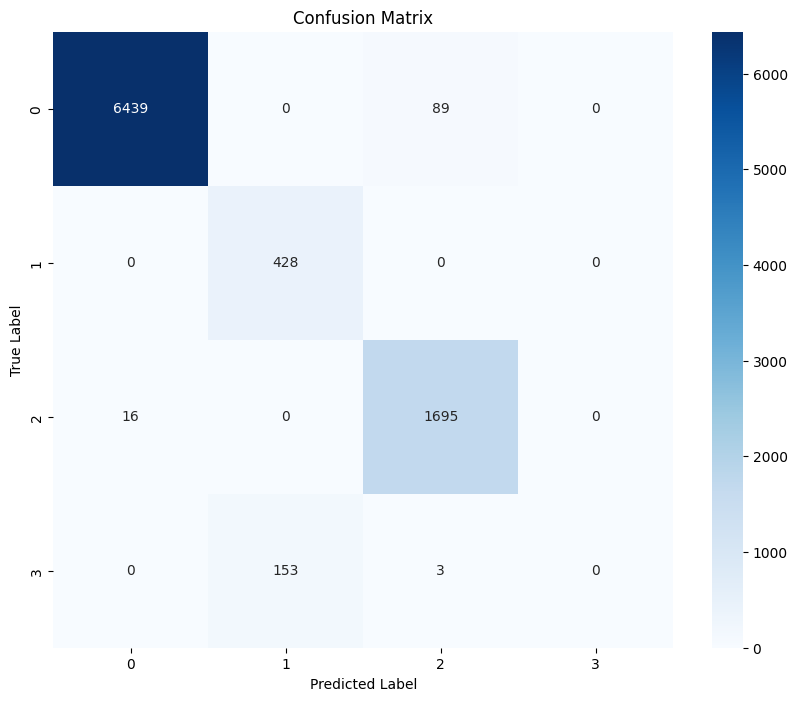

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k=4
batch_size=100
max_iter=100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

n_estimators=100
learning_rate=0.01
adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)
adaboost_classifier.fit(train, train_labels)

predictions = adaboost_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of AdaBoost Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary ADABOOST CLASSIFIER GMM
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.3, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    n_estimators, learning_rate = params

    adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        adaboost_classifier.fit(train.iloc[train_index], train_labels)
        predictions = adaboost_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1
2
3
4
5
6
7
8
9
10
11
12
Best hyperparameters: {'n_estimators': 50, 'learning_rate': 1.0}
Best accuracy: 0.9702465287616888


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy of AdaBoost Classifier with GMM cluster labels: 0.9713249461634365
Precision: 0.9582847022912245
Recall: 0.9713249461634365
F1-score: 0.9637789188093205
Confusion Matrix:
 [[6553   47    0    0]
 [  48 1594    0    0]
 [   0    0  423    0]
 [   0    0  158    0]]


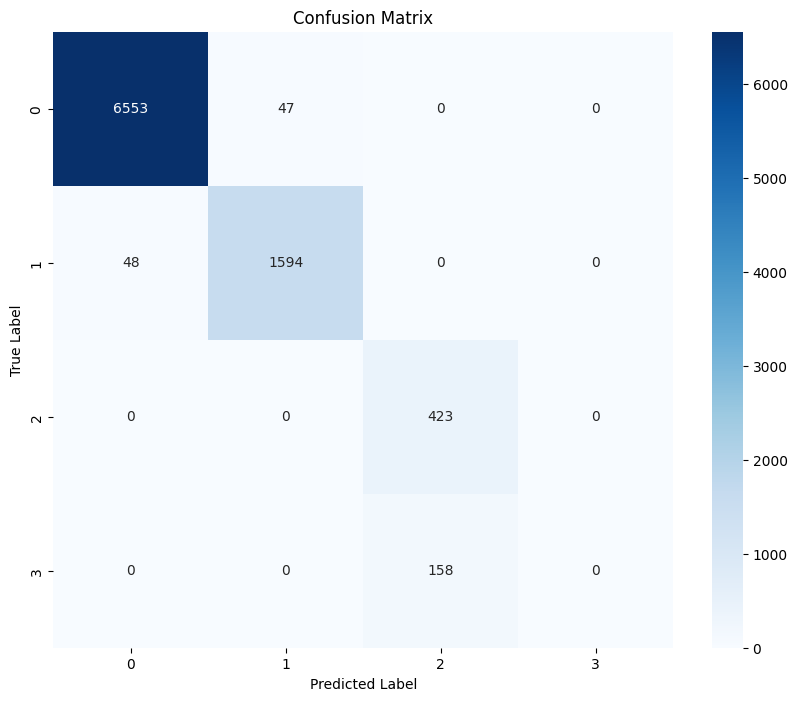

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

n_estimators=50
learning_rate=1.0

adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)

adaboost_classifier.fit(train, train_labels)
predictions = adaboost_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of AdaBoost Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary AdaBoost K-Means
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.3, 1.0],
}
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    n_estimators, learning_rate = params

    adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        adaboost_classifier.fit(train.iloc[train_index], train_labels)
        predictions = adaboost_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

11


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

12


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'n_estimators': 50, 'learning_rate': 0.01}
Best accuracy: 0.9554264664210825


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy of AdaBoost Classifier with K-Means cluster labels: 0.9562507083758359
Precision: 0.9424788291085695
Recall: 0.9562507083758359
F1-score: 0.9487242367029645
Confusion Matrix:
 [[1107    0   40   60    0]
 [  22  402    0    0    0]
 [  33    0 5883    0    0]
 [  75    0    0 1045    0]
 [  14  139    0    3    0]]


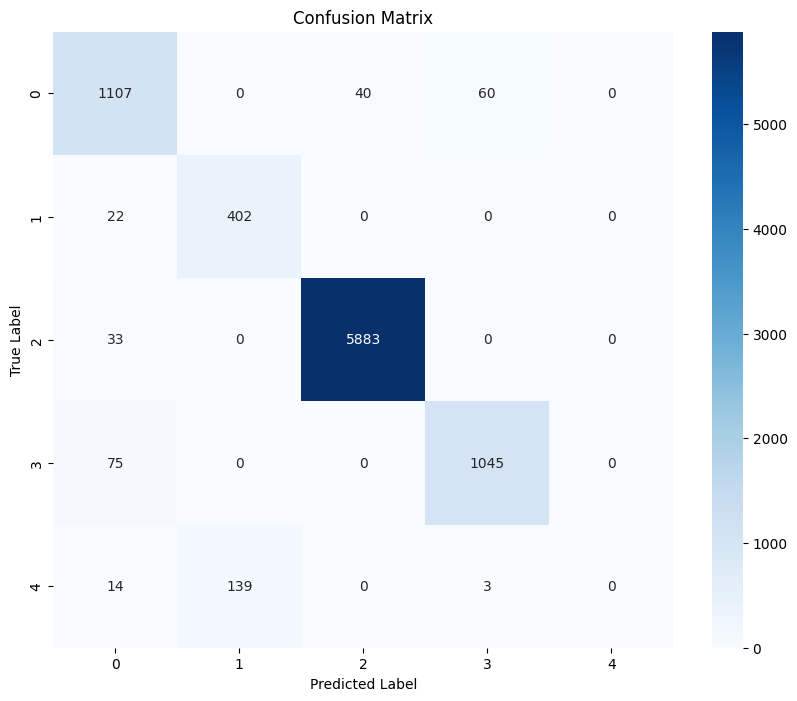

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

n_estimators=50
learning_rate=0.01

adaboost_classifier = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                             random_state=42)
adaboost_classifier.fit(train, train_labels)
predictions = adaboost_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of AdaBoost Classifier with K-Means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary Random Forest Classifier Minibatch K-Means
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

n_estimators_list = [50, 100, 150]
max_depth_list = [None, 5, 10]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = ['auto', 'sqrt', 'log2']

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a=0

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            for min_samples_leaf in min_samples_leaf_list:
                for max_features in max_features_list:
                    a=a+1
                    print(a)
                    rf_classifier = RandomForestClassifier(n_estimators=n_estimators,
                                                            max_depth=max_depth,
                                                            min_samples_split=min_samples_split,
                                                            min_samples_leaf=min_samples_leaf,
                                                            max_features=max_features,
                                                            random_state=42)
                    fold_accuracies = []

                    for train_index, test_index in kf.split(train):
                        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
                        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
                        rf_classifier.fit(train.iloc[train_index], train_labels)
                        predictions = rf_classifier.predict(train.iloc[test_index])
                        fold_accuracy = accuracy_score(test_labels, predictions)
                        fold_accuracies.append(fold_accuracy)
                    mean_accuracy = np.mean(fold_accuracies)
                    if mean_accuracy > best_accuracy:
                        best_accuracy = mean_accuracy
                        best_params = {'n_estimators': n_estimators,
                                       'max_depth': max_depth,
                                       'min_samples_split': min_samples_split,
                                       'min_samples_leaf': min_samples_leaf,
                                       'max_features': max_features}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

206


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

207


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
